In [3]:
# !pip install pdfplumber pandas numpy
import pdfplumber
import pandas as pd
import numpy as np

# Filenames as provided
options_file = "options_maratoia.pdf"
results_file = "results_maratoia.pdf"

In [12]:
def extract_options_data(pdf_path):
    data = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            # extract_table handles the grid-like structure of Zegama PDFs
            table = page.extract_table()
            if table:
                # Assuming headers are: [Surname, Name, Options] 
                # Zegama often uses: [Abizena, Izena, Aukerak]
                for row in table[1:]: # Skip header
                    if row and len(row) >= 3:
                        # Clean the data
                        surname = str(row[0]).strip()
                        name = str(row[1]).strip()
                        try:
                            options = int(row[-1])
                        except:
                            options = 1 # Default
                        
                        data.append({
                            'full_name': f"{surname} {name}".upper(),
                            'options': options
                        })
    return pd.DataFrame(data)

df_participants = extract_options_data(options_file)
print(f"Total applicants extracted: {len(df_participants)}")
df_participants.head()

Total applicants extracted: 11392


,full_name,options
0,"AARAB, MOHA",3
1,"AASE, PREBEN",1
2,"ABAD ABAD, MIGUEL",1
3,"ABAD ALONSO, FELIX",1
4,"ABAD DE LA FUENTE, JAVIER",8


In [17]:
df_participants[80:100]

,full_name,options
80,"AGORRETA SANZ, JAVIER",9
81,"AGORRIA MENDIKUTE, FELIX",2
82,"AGRAMUNT YUBERO, JOSÉ ANTONIO",4
83,"AGRAS PITA, EDGAR",4
84,"AGUADÉ VIDAL, DAVID",1
85,"AGUADO FERNANDEZ, LORENZO",7
86,"AGUADO GARCIA, JULEN",5
87,"AGUADO GARMENDIA, XABIER",3
88,"AGUADO IVORRA, PABLO",2
89,"AGUADO JARAUTA, EZEQUIEL",3


In [18]:
def extract_winners_list(pdf_path):
    winners = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text:
                # Zegama winners list is often a simple text list or a table
                # We normalize to uppercase for easier matching
                lines = text.split('\n')
                for line in lines:
                    if len(line.strip()) > 5: # Filter out short noise
                        winners.append(line.strip().upper())
    return winners

winners_list = extract_winners_list(results_file)
print(f"Total winners extracted: {len(winners_list)}")

Total winners extracted: 255


In [20]:
# 1. Add 'selected' boolean
# We use a simple substring match to handle slight formatting differences
df_participants['selected'] = df_participants['full_name'].apply(
    lambda x: any(x in winner or winner in x for winner in winners_list)
)

# 2. Calculate Stats
total_tickets = df_participants['options'].sum()
num_spots = 225 # Standard Zegama lottery spots

# 3. Calculate Odds
df_participants['probability'] = 1 - (1 - (df_participants['options'] / total_tickets))**num_spots

# 4. Final Array Format (as you requested)
# Array of [Name, Options, Selected_Bool, Probability]
participants_array = df_participants[['full_name', 'options', 'selected', 'probability']].values

print(f"Winners found in participants list: {df_participants['selected'].sum()}")
df_participants.sort_values(by='probability', ascending=False).head(40)

Winners found in participants list: 226


,full_name,options,selected,probability
9231,"RODRÍGUEZ MAÑERU, JUAN",16,False,0.089672
6018,"LOPEZ CASTILLO, PEDRO",15,False,0.084310
1946,"CAÑAS GONZALEZ, ALBERT",15,False,0.084310
4687,"GONZALEZ RESBIER, DAVID",15,False,0.084310
4224,"GARCIA VIÑAS, JOEL",15,False,0.084310
7817,"OLLES PASCUAL, AGUSTIN",15,False,0.084310
5415,"JAUREGI OTEGI, HARITZ",14,False,0.078917
7772,"OLAIZOLA BORDA, MIKEL",14,False,0.078917
9459,"RUBIO MARTÍNEZ, PATXI",14,False,0.078917
7568,"MUZAS COLERA, IKER",14,False,0.078917


         Total People  Actual Winners  Theoretical Prob  Actual Rate
options                                                             
1                3319              24          0.005854     0.007231
2                2167              30          0.011673     0.013844
3                1557              25          0.017459     0.016057
4                1535              46          0.023210     0.029967
5                 792              20          0.028929     0.025253
6                 599              18          0.034614     0.030050
7                 389               9          0.040265     0.023136
8                 400              24          0.045884     0.060000
9                 277              13          0.051471     0.046931
10                180               7          0.057024     0.038889
11                 95               4          0.062545     0.042105
12                 41               2          0.068034     0.048780
13                 26             

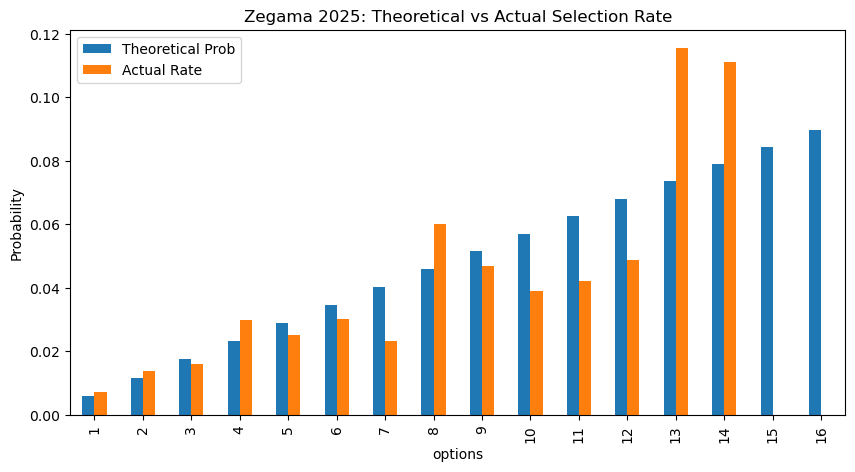

In [21]:
import matplotlib.pyplot as plt

# Probability of selection by number of options
stats = df_participants.groupby('options').agg({
    'selected': ['count', 'sum'],
    'probability': 'mean'
})
stats.columns = ['Total People', 'Actual Winners', 'Theoretical Prob']
stats['Actual Rate'] = stats['Actual Winners'] / stats['Total People']

print(stats)

# Plotting the gap between Theory and Reality
stats[['Theoretical Prob', 'Actual Rate']].plot(kind='bar', figsize=(10, 5))
plt.title("Zegama 2025: Theoretical vs Actual Selection Rate")
plt.ylabel("Probability")
plt.show()

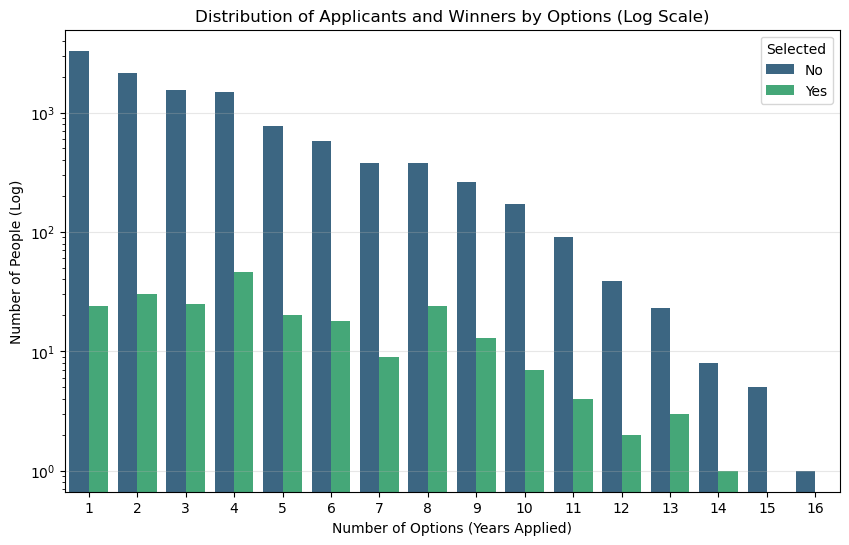

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of participants by number of options
plt.figure(figsize=(10, 6))
sns.countplot(data=df_participants, x='options', hue='selected', palette='viridis')
plt.yscale('log') # Log scale helps see the winners in low-option tiers
plt.title("Distribution of Applicants and Winners by Options (Log Scale)")
plt.xlabel("Number of Options (Years Applied)")
plt.ylabel("Number of People (Log)")
plt.legend(title="Selected", labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.3)
plt.show()

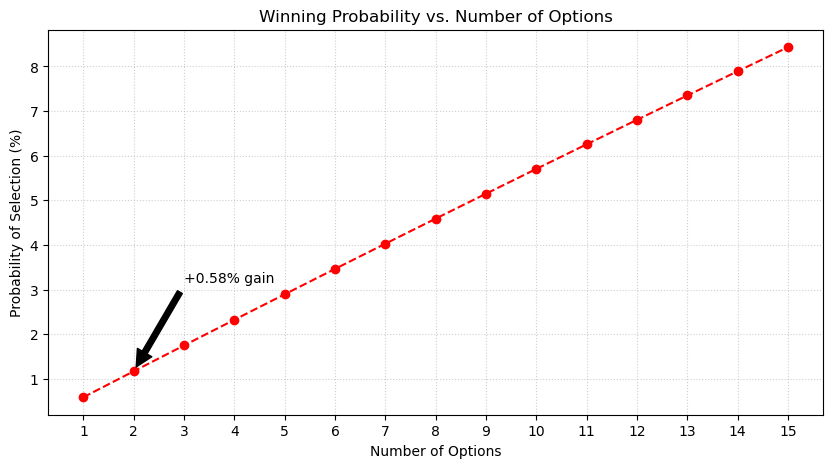

In [23]:
# Calculate probability for a range of options (e.g., 1 to 15)
option_range = np.arange(1, 16)
total_tickets = df_participants['options'].sum()
num_spots = 225

probs = [1 - (1 - (o / total_tickets))**num_spots for o in option_range]

plt.figure(figsize=(10, 5))
plt.plot(option_range, [p * 100 for p in probs], marker='o', linestyle='--', color='red')
plt.title("Winning Probability vs. Number of Options")
plt.xlabel("Number of Options")
plt.ylabel("Probability of Selection (%)")
plt.xticks(option_range)
plt.grid(True, linestyle=':', alpha=0.6)

# Annotate the gain from 1 to 2 options
gain = (probs[1] - probs[0]) * 100
plt.annotate(f'+{gain:.2f}% gain', xy=(2, probs[1]*100), xytext=(3, probs[1]*100 + 2),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

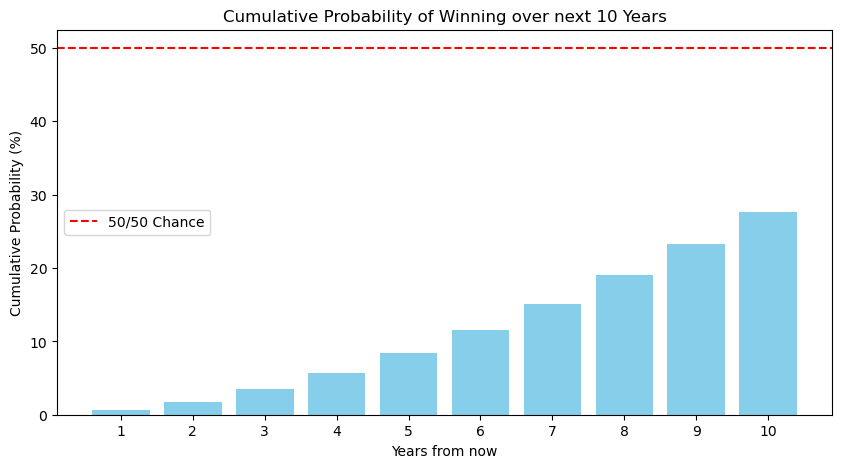

In [24]:
def calculate_cumulative_prob(start_options, years, total_tix, spots):
    prob_failure = 1.0
    for i in range(years):
        # We assume total_tickets in the pool stays roughly constant
        current_options = start_options + i
        p_win_this_year = 1 - (1 - (current_options / total_tix))**spots
        prob_failure *= (1 - p_win_this_year)
    return 1 - prob_failure

years_to_forecast = 10
my_current_options = 1 # Change this to your current options

cumulative_probs = [calculate_cumulative_prob(my_current_options, y, total_tickets, num_spots) 
                   for y in range(1, years_to_forecast + 1)]

plt.figure(figsize=(10, 5))
plt.bar(range(1, years_to_forecast + 1), [p * 100 for p in cumulative_probs], color='skyblue')
plt.title(f"Cumulative Probability of Winning over next {years_to_forecast} Years")
plt.xlabel("Years from now")
plt.ylabel("Cumulative Probability (%)")
plt.xticks(range(1, years_to_forecast + 1))
plt.axhline(y=50, color='r', linestyle='--', label="50/50 Chance")
plt.legend()
plt.show()